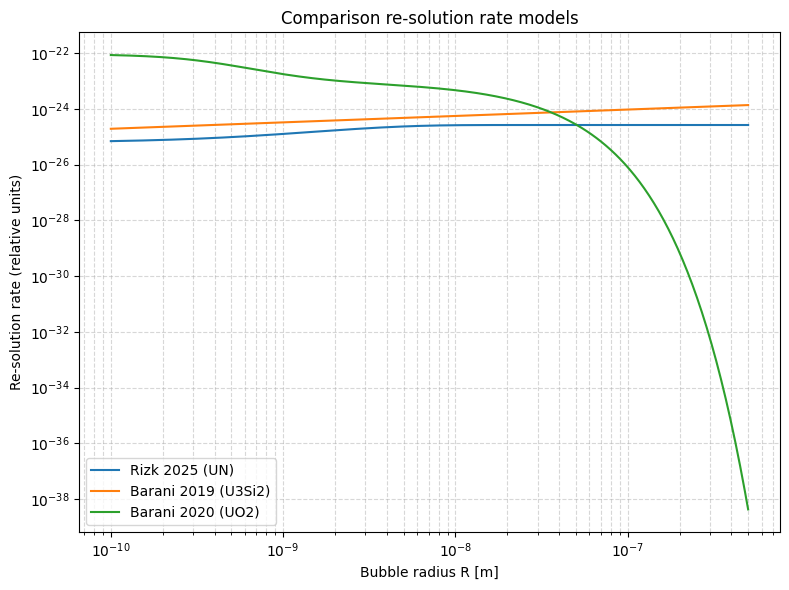

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# RANGE DI RAGGI (m)
# =========================================================
R_min = 1e-10   # 0.1 nm
R_max = 5e-7    # 500 nm

R = np.logspace(np.log10(R_min), np.log10(R_max), 400)
# =========================================================
# 1. RIZK (2025) – UN
# =========================================================
def b0_rizk(R):
    return 1e-25 * (2.64 - 2.02 * np.exp(-R / (2.61e-9)))

# =========================================================
# 2. BARANI (2019) – U3Si2
# =========================================================
def alpha0_barani2019(R):
    return 2.80e-25 * (R / (5e-10))**0.23

# =========================================================
# 3. BARANI (2020) – UO2 (solo parte R-dipendente, Fdot=1)
# =========================================================
def alpha_barani2020(R):
    a = 9.49e-24
    b0 = 9.18e-23
    b1 = 7.07e7
    c = 7.982e18
    d = 3.71e16

    term1 = a * np.exp(-b1 * R)
    term2 = (b0 - a) / (1 + c * R**2) * np.exp(-d * R**2)

    return (term1 + term2)  # * Fdot (messo =1 per confronto relativo)

# =========================================================
# CALCOLO
# =========================================================
b_rizk = b0_rizk(R)
b_barani19 = alpha0_barani2019(R)
b_barani20 = alpha_barani2020(R)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(8,6))

plt.loglog(R, b_rizk, label="Rizk 2025 (UN)")
plt.loglog(R, b_barani19, label="Barani 2019 (U3Si2)")
plt.loglog(R, b_barani20, label="Barani 2020 (UO2)")

plt.xlabel("Bubble radius R [m]")
plt.ylabel("Re-solution rate (relative units)")
plt.title("Comparison re-solution rate models")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()